In [18]:
import yfinance as yf
import pandas as pd
import numpy as np
import warnings
import matplotlib.pyplot as plt
from scipy.linalg import eigh
from sklearn.cluster import KMeans
import networkx as nx
warnings.filterwarnings('ignore')

# =============================================================================
# BLOQUE 1: DESCARGA Y PREPROCESAMIENTO DE LA RED BURSÁTIL
# =============================================================================

print("1. Cargando el universo de inversión...")

# Universo de inversión autocontenido y estructurado por sectores reales
universo_sectores = {
    'Tecnologia': [
        'AAPL', 'MSFT', 'NVDA', 'GOOGL', 'META', 'AMZN', 'NFLX', 'INTC', 'CSCO', 'ADBE', 
        'CRM', 'QCOM', 'AMD', 'TXN', 'AVGO', 'IBM', 'NOW', 'INTU', 'AMAT', 'MU', 
        'ORCL', 'PANW', 'FTNT', 'KLAC', 'SNPS', 'CDNS', 'ROP', 'TEL', 'HPQ', 'GLW',
        'STX', 'WDC', 'NTAP', 'PTC', 'TYL', 'AKAM', 'FSLR', 'ENPH', 'SEDG', 'QRVO'
    ],
    'Finanzas': [
        'JPM', 'BAC', 'GS', 'MS', 'C', 'WFC', 'V', 'MA', 'AXP', 'SPGI', 
        'BLK', 'SCHW', 'CB', 'MMC', 'PGR', 'USB', 'PNC', 'TFC', 'CME', 'ICE', 
        'AON', 'COF', 'BK', 'MET', 'PRU', 'AIG', 'TRV', 'ALL', 'DFS', 'SYF',
        'MTB', 'FITB', 'AMP', 'STT', 'NTRS', 'PFG', 'HIG', 'CMA', 'KEY', 'CFG'
    ],
    'Salud': [
        'JNJ', 'PFE', 'UNH', 'ABBV', 'LLY', 'MRK', 'TMO', 'DHR', 'ABT', 'AMGN', 
        'ISRG', 'SYK', 'MDT', 'VRTX', 'REGN', 'ZTS', 'BDX', 'BSX', 'GILD', 'HUM', 
        'CNC', 'EW', 'CAH', 'MCK', 'BIIB', 'IDXX', 'IQV', 'MTD', 'A', 'ILMN',
        'DXCM', 'ALGN', 'ZBH', 'BAX', 'STE', 'HOLX', 'WAT', 'PKI', 'CRL', 'BIO'
    ],
    'Energia': [
        'XOM', 'CVX', 'COP', 'SLB', 'EOG', 'MPC', 'PSX', 'VLO', 'OXY', 'HES', 
        'BKR', 'HAL', 'WMB', 'KMI', 'TRGP', 'FANG', 'DVN', 'CTRA', 'MRO', 'EQT', 
        'OKE', 'APA', 'MTDR', 'CHRD', 'OVV', 'CIVI', 'MUSA', 'SM', 'CRK', 'BTU',
        'AR', 'CNX', 'MUR', 'NOG', 'PR', 'WTI', 'LPI', 'CPE', 'TALO', 'HP'
    ]
}

# Aplanamos el diccionario para obtener la lista final de tickers
tickers = []
etiquetas_reales = {}
for sector, lista_acciones in universo_sectores.items():
    tickers.extend(lista_acciones)
    for accion in lista_acciones:
        etiquetas_reales[accion] = sector

print(f"Total de activos identificados: {len(tickers)}")

print("\n2. Descargando 10 años de historia bursátil (puede tomar un minuto)...")
data = yf.download(tickers, start="2014-01-01", end="2024-01-01")['Close']

# Eliminamos activos que no tienen la historia completa de 10 años
data = data.dropna(axis=1)

# Actualizamos nuestra lista de nodos válidos y sus sectores reales
nodos_validos = data.columns.tolist()
etiquetas_validas = [etiquetas_reales[nodo] for nodo in nodos_validos]

print("\n3. Calculando la matriz de correlación (Aristas de la red)...")
retornos = data.pct_change().dropna()
matriz_correlacion = retornos.corr()

n_nodos = matriz_correlacion.shape[0]
print(f"\n¡Red masiva construida exitosamente!")
print(f"Nodos finales de la red (n): {n_nodos}")
print(f"Días de cotización procesados por nodo: {len(retornos)}")

1. Cargando el universo de inversión...
Total de activos identificados: 160

2. Descargando 10 años de historia bursátil (puede tomar un minuto)...


[****                   9%                       ]  14 of 160 completed$PKI: possibly delisted; no timezone found
[*****                 10%                       ]  16 of 160 completed$HES: possibly delisted; no timezone found
[*********             18%                       ]  28 of 160 completed$HOLX: possibly delisted; no timezone found
[********************  42%                       ]  67 of 160 completed$CTRA: possibly delisted; no timezone found
[**********************51%                       ]  81 of 160 completed$BK: possibly delisted; no timezone found
[**********************54%*                      ]  87 of 160 completed$CIVI: possibly delisted; no timezone found
[**********************63%*****                  ]  101 of 160 completed$MRO: possibly delisted; no timezone found
[**********************64%******                 ]  102 of 160 completed$LPI: possibly delisted; no timezone found
[**********************71%*********              ]  114 of 160 completed$CPE: possib


3. Calculando la matriz de correlación (Aristas de la red)...

¡Red masiva construida exitosamente!
Nodos finales de la red (n): 141
Días de cotización procesados por nodo: 2515


In [19]:
# =============================================================================
# BLOQUE 2: CONSTRUCCIÓN DE MATRICES (A, D, L)
# =============================================================================

print("\n4. Aplicando filtros metodológicos para construir la Matriz de Adyacencia (A)...")

# Decisión 1: Definir umbral de similitud (filtro de ruido)
umbral = 0.40

# Convertimos la matriz de correlación de pandas a un array de numpy (A)
A = matriz_correlacion.values.copy()

# Hacemos 0 todos los valores por debajo del umbral y los valores negativos
A[A < umbral] = 0

# Decisión 2: Eliminar loops (forzar la diagonal a 0)
np.fill_diagonal(A, 0)

print("5. Calculando la Matriz de Grados (D) y el Laplaciano (L)...")
# Matriz de Grados (D): Suma de las filas de A colocada en la diagonal
grados = np.sum(A, axis=1)
D = np.diag(grados)

# Matriz Laplaciana (L = D - A)
L = D - A

print(f"\n¡Matrices construidas con éxito!")
print(f"Forma de A: {A.shape} | Forma de D: {D.shape} | Forma de L: {L.shape}")
print(f"Grado promedio de la red (nodos conectados): {np.mean(grados):.2f}")


4. Aplicando filtros metodológicos para construir la Matriz de Adyacencia (A)...
5. Calculando la Matriz de Grados (D) y el Laplaciano (L)...

¡Matrices construidas con éxito!
Forma de A: (141, 141) | Forma de D: (141, 141) | Forma de L: (141, 141)
Grado promedio de la red (nodos conectados): 28.14



6. Calculando Valores y Vectores Propios del Laplaciano...


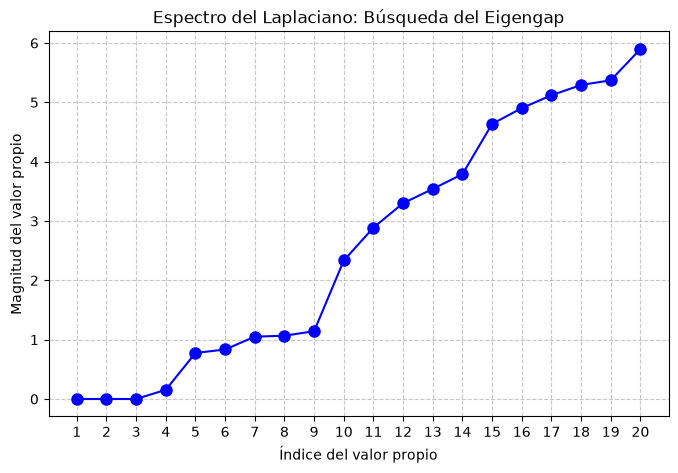


7. Construyendo representación espectral (Matriz U) con k=4...
8. Ejecutando algoritmo K-Means sobre la representación espectral...

¡Clustering completado con éxito!
Revisa la pestaña 'Plots' (Gráficos) en Spyder para ver la curva del Eigengap.


In [20]:
# =============================================================================
# BLOQUE 3: EL MOTOR ESPECTRAL Y K-MEANS
# =============================================================================

print("\n6. Calculando Valores y Vectores Propios del Laplaciano...")
# Usamos 'eigh' de scipy, que está optimizado matemáticamente para matrices simétricas como L
valores_propios, vectores_propios = eigh(L)

# Aseguramos que estén ordenados de menor a mayor (como dicta la teoría)
idx = np.argsort(valores_propios)
valores_propios = valores_propios[idx]
vectores_propios = vectores_propios[:, idx]

# --- Visualización del Eigengap (Requisito Sección 5.5) ---
plt.figure(figsize=(8, 5))
plt.plot(range(1, 21), valores_propios[:20], 'bo-', markersize=8)
plt.title('Espectro del Laplaciano: Búsqueda del Eigengap')
plt.xlabel('Índice del valor propio')
plt.ylabel('Magnitud del valor propio')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(range(1, 21))
plt.savefig("graph1.png", dpi=300, bbox_inches="tight")

plt.show()
# --- Clustering Espectral ---
# Nuestro objetivo analítico es ver si el algoritmo reconstruye los 4 sectores reales (Tecnología, Finanzas, Salud, Energía).
# Por ende, definimos k=4.
k = 4
print(f"\n7. Construyendo representación espectral (Matriz U) con k={k}...")

# Matriz U: extraemos las primeras k columnas (los k vectores propios asociados a los autovalores más pequeños)
U = vectores_propios[:, 0:k]

print("8. Ejecutando algoritmo K-Means sobre la representación espectral...")
# Ejecutamos k-means interpretando cada fila de U como un punto en R^k
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
etiquetas_predichas = kmeans.fit_predict(U)

print(f"\n¡Clustering completado con éxito!")
print("Revisa la pestaña 'Plots' (Gráficos) en Spyder para ver la curva del Eigengap.")

9. Construyendo el grafo topológico desde la Matriz de Adyacencia (A)...
10. Dibujando las comunidades descubiertas...


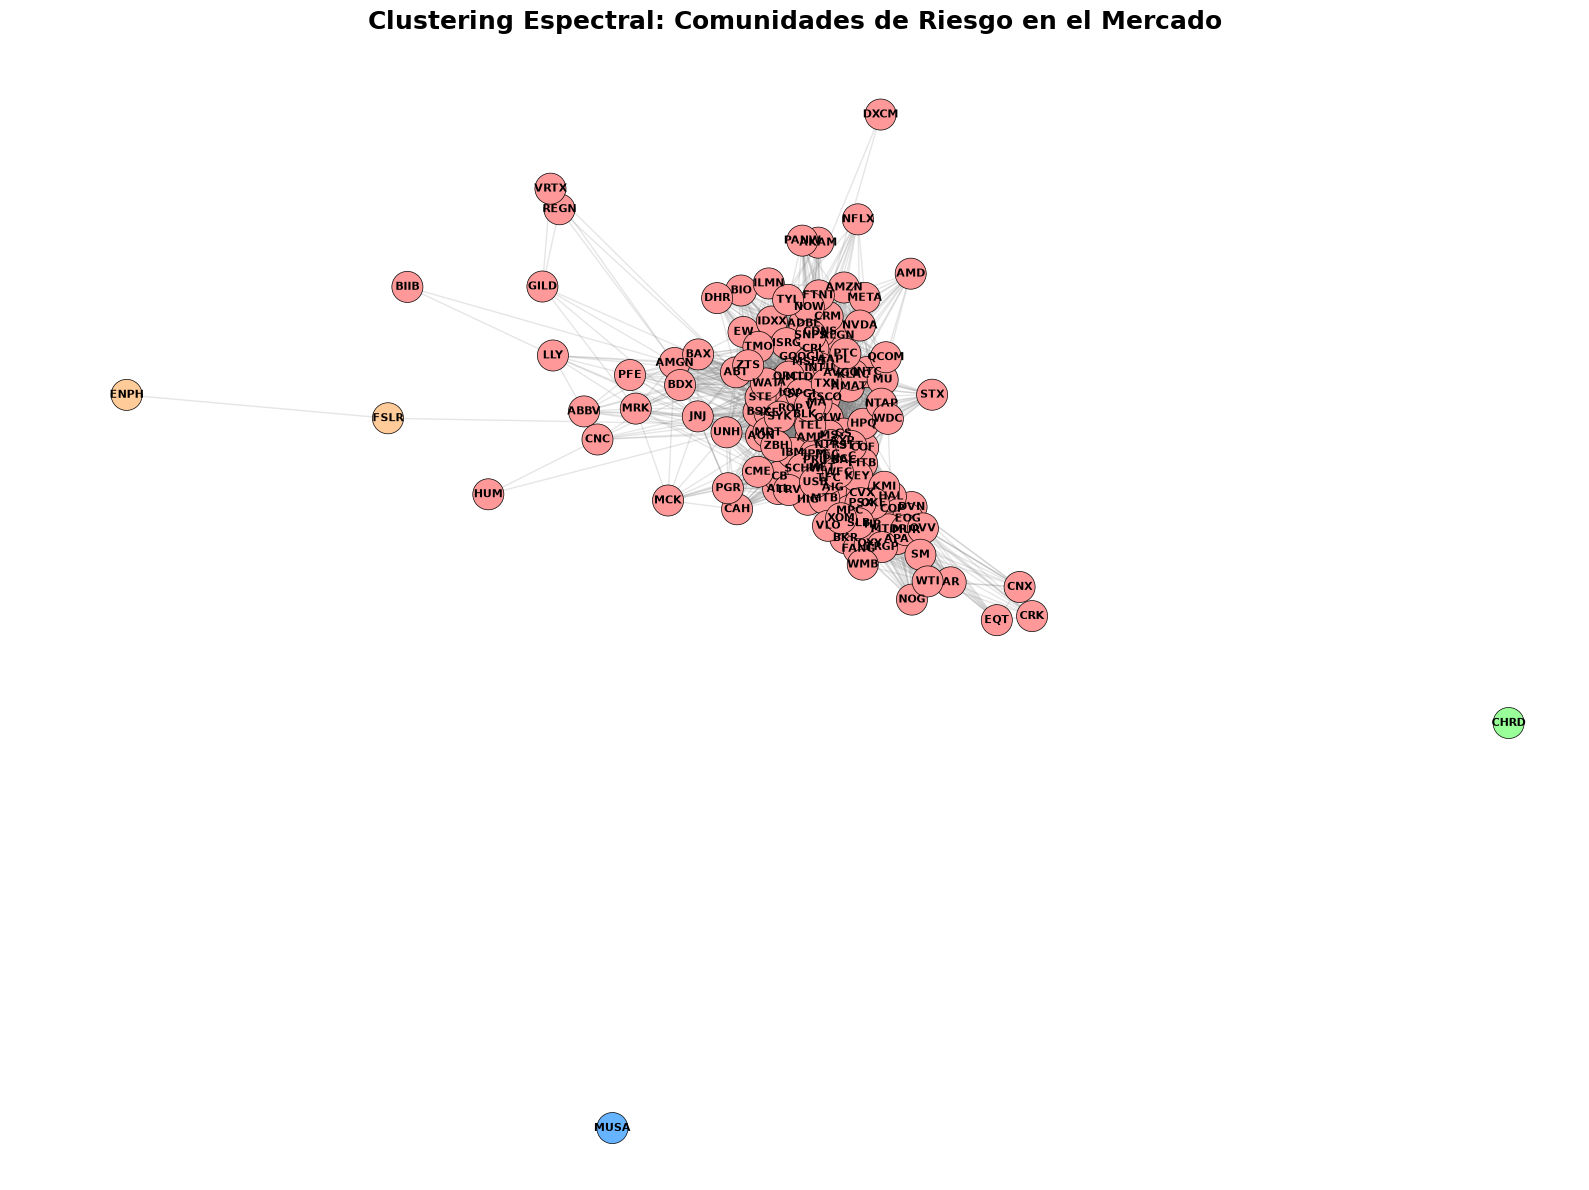

In [21]:
# =============================================================================
# BLOQUE 4: VISUALIZACIÓN DE LA RED BURSÁTIL Y COMUNIDADES
# =============================================================================

print("9. Construyendo el grafo topológico desde la Matriz de Adyacencia (A)...")
# Creamos el grafo directamente desde nuestra matriz matemática A
G = nx.from_numpy_array(A)

# Renombramos los nodos (cambiamos los números de índice por los Tickers reales)
mapping = {i: nodos_validos[i] for i in range(len(nodos_validos))}
G = nx.relabel_nodes(G, mapping)

# Calculamos la disposición espacial. 'spring_layout' simula resortes físicos:
# junta los nodos altamente correlacionados y aleja los que no tienen conexión.
pos = nx.spring_layout(G, seed=42, k=0.20)

print("10. Dibujando las comunidades descubiertas...")
plt.figure(figsize=(16, 12))

# Asignamos una paleta de 4 colores claros para los 4 clústeres descubiertos
colores = ['#ff9999', '#66b3ff', '#99ff99', '#ffcc99']
color_map = [colores[cluster] for cluster in etiquetas_predichas]

# Dibujamos los componentes de la red
nx.draw_networkx_nodes(G, pos, node_color=color_map, node_size=500, edgecolors='black', linewidths=0.5)
nx.draw_networkx_edges(G, pos, alpha=0.2, edge_color='gray')
nx.draw_networkx_labels(G, pos, font_size=8, font_family='sans-serif', font_weight='bold')

plt.title("Clustering Espectral: Comunidades de Riesgo en el Mercado", fontsize=18, fontweight='bold')
plt.axis('off') # Ocultamos los ejes para que se vea como un mapa puro
plt.tight_layout()
plt.savefig("graph2.png", dpi=300, bbox_inches="tight")

plt.show()
# 1. Guarda el archivo con extensión explícita

# 2. Si quieres seguir viéndolo en el notebook


1. Calculando el Laplaciano Normalizado...
2. Motor Espectral Normalizado...
3. Ejecutando K-Means sobre la nueva topología...
4. Dibujando el nuevo grafo (El resultado real)...


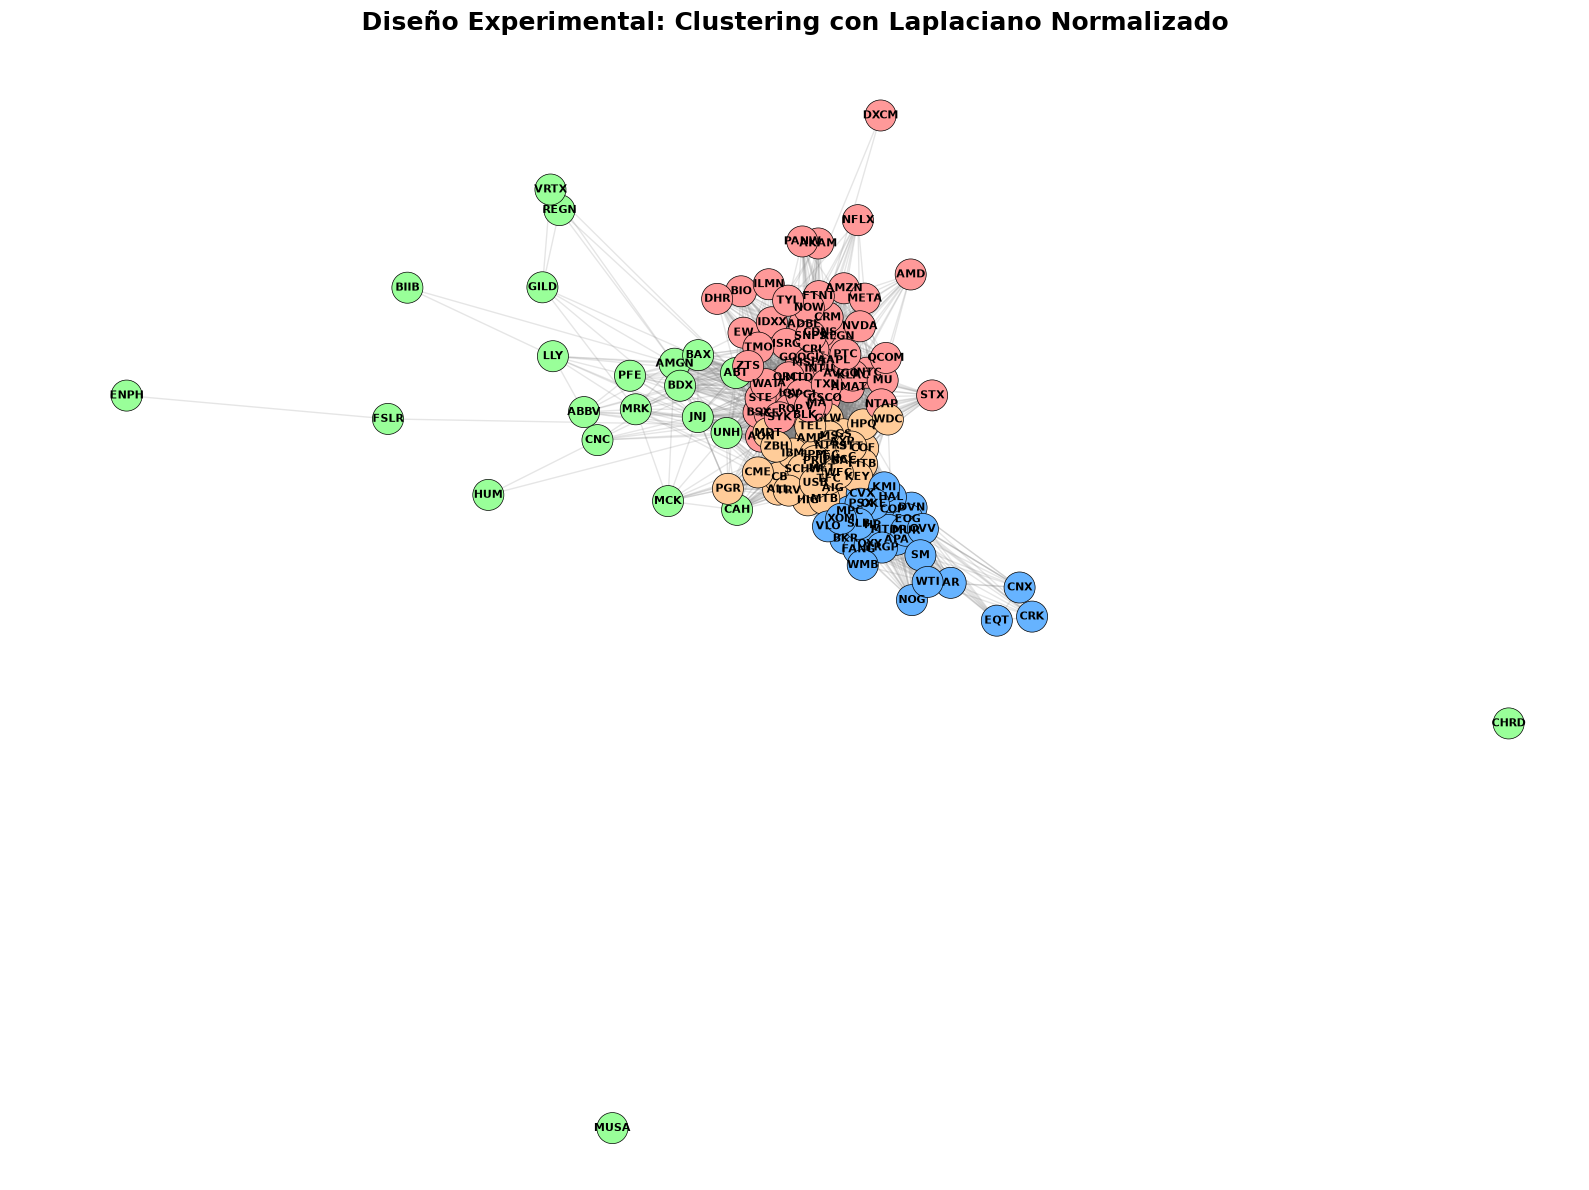

In [22]:
# =============================================================================
# BLOQUE 5: DISEÑO EXPERIMENTAL - LAPLACIANO NORMALIZADO
# =============================================================================

print("1. Calculando el Laplaciano Normalizado...")
# Para evitar división por cero en nodos aislados, sumamos un valor ínfimo (1e-10)
grados_seguros = np.diag(D) + 1e-10
D_inv_sqrt = np.diag(1.0 / np.sqrt(grados_seguros))

# Fórmula del Laplaciano Normalizado: I - D^{-1/2} * A * D^{-1/2}
I = np.eye(len(A))
L_norm = I - np.dot(D_inv_sqrt, np.dot(A, D_inv_sqrt))

print("2. Motor Espectral Normalizado...")
valores_norm, vectores_norm = eigh(L_norm)

# Ordenamos
idx_n = np.argsort(valores_norm)
vectores_norm = vectores_norm[:, idx_n]

# Extraemos las primeras k=4 columnas
U_norm = vectores_norm[:, 0:4]

# TRUCO MATEMÁTICO: En el Laplaciano Normalizado, se recomienda normalizar 
# las filas de U para que k-means funcione perfectamente en la esfera geométrica.
normas = np.linalg.norm(U_norm, axis=1, keepdims=True)
U_norm = U_norm / (normas + 1e-10)

print("3. Ejecutando K-Means sobre la nueva topología...")
kmeans_norm = KMeans(n_clusters=4, random_state=42, n_init=10)
etiquetas_norm = kmeans_norm.fit_predict(U_norm)

print("4. Dibujando el nuevo grafo (El resultado real)...")
plt.figure(figsize=(16, 12))
color_map_norm = [colores[cluster] for cluster in etiquetas_norm]

# Usamos las mismas posiciones 'pos' del bloque anterior para comparar manzanas con manzanas
nx.draw_networkx_nodes(G, pos, node_color=color_map_norm, node_size=500, edgecolors='black', linewidths=0.5)
nx.draw_networkx_edges(G, pos, alpha=0.2, edge_color='gray')
nx.draw_networkx_labels(G, pos, font_size=8, font_family='sans-serif', font_weight='bold')

plt.title("Diseño Experimental: Clustering con Laplaciano Normalizado", fontsize=18, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.savefig("graph3.png", dpi=300, bbox_inches="tight")

plt.show()



Número de nodos (n): 141
Número de aristas (|E|): 3847
Densidad de la red: 0.3898
Componentes conexas: 3 | Nodos aislados: 2


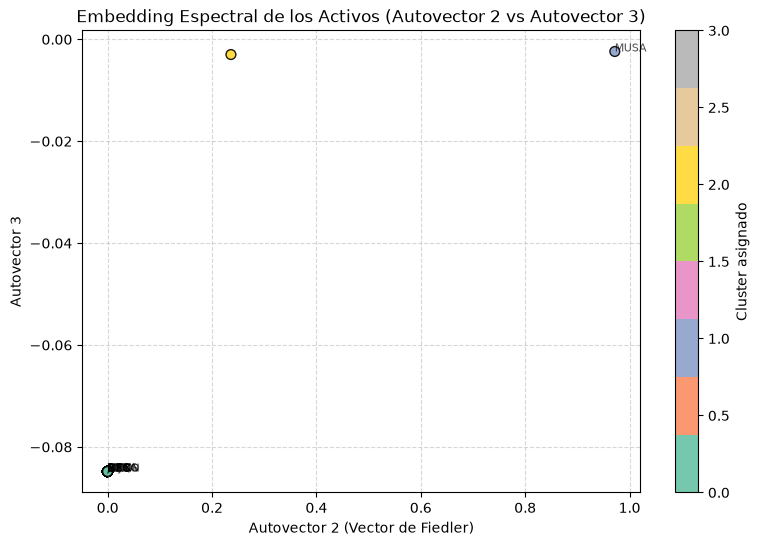

--- Métricas de Calidad de Partición ---
Adjusted Rand Index (ARI): 0.0015
Normalized Mutual Information (NMI): 0.0526
Silhouette Score (Espacio Espectral): 0.9784
Modularidad de la Red (Q): 0.0004

Distribución de Sectores en Comunidades:
Cluster      Cluster 0  Cluster 1  Cluster 2  Cluster 3
Sector Real                                            
Energia             29          1          1          0
Finanzas            34          0          0          0
Salud               38          0          0          0
Tecnologia          36          0          0          2

--- Comparación Experimental (Sección 5.4) ---
ARI - Laplaciano No Normalizado (L): 0.0015
ARI - Laplaciano Normalizado Simétrico (L_sym): 0.4795
ARI - Scikit-Learn SpectralClustering: -0.0020

--- Extensión (Sección 5.6) ---
Comunidades detectadas por Louvain: 6
Modularidad Spectral: 0.0004 vs Modularidad Louvain: 0.2397


In [23]:
# =============================================================================
# BLOQUE 5: DIAGNÓSTICO TOPOLÓGICO Y COMPONENTES (Secciones 5.1 y 5.2)
# =============================================================================
import networkx as nx
import networkx.algorithms.community as nx_comm
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, silhouette_score
from sklearn.cluster import SpectralClustering
from sklearn.preprocessing import normalize
import seaborn as sns

n_aristas = G.number_of_edges()
densidad = nx.density(G)
n_componentes = nx.number_connected_components(G)
nodos_aislados = list(nx.isolates(G))

print(f"Número de nodos (n): {G.number_of_nodes()}")
print(f"Número de aristas (|E|): {n_aristas}")
print(f"Densidad de la red: {densidad:.4f}")
print(f"Componentes conexas: {n_componentes} | Nodos aislados: {len(nodos_aislados)}")

# =============================================================================
# BLOQUE 6: VISUALIZACIÓN DEL EMBEDDING ESPECTRAL (Secciones 5.3 y 5.5)
# =============================================================================
plt.figure(figsize=(9, 6))
# Proyección en los autovectores 2 y 3 (v_2 es el vector de Fiedler)
scatter = plt.scatter(U[:, 1], U[:, 2], c=etiquetas_predichas, cmap='Set2', s=50, alpha=0.9, edgecolors='k')
plt.title("Embedding Espectral de los Activos (Autovector 2 vs Autovector 3)")
plt.xlabel("Autovector 2 (Vector de Fiedler)")
plt.ylabel("Autovector 3")
plt.grid(True, linestyle='--', alpha=0.5)

# Anotar algunos activos relevantes
for i, ticker in enumerate(nodos_validos):
    if i % 10 == 0:  # Muestra para evitar saturar el gráfico
        plt.annotate(ticker, (U[i, 1], U[i, 2]), fontsize=8, alpha=0.7)
plt.colorbar(scatter, label='Cluster asignado')
plt.savefig("graph4.png", dpi=300, bbox_inches="tight")
plt.show()

# =============================================================================
# BLOQUE 7: EVALUACIÓN CUANTITATIVA Y MATRIZ DE CONFUSIÓN (Sección 5.5)
# =============================================================================
ari = adjusted_rand_score(etiquetas_validas, etiquetas_predichas)
nmi = normalized_mutual_info_score(etiquetas_validas, etiquetas_predichas)
sil = silhouette_score(U, etiquetas_predichas)

# Modularidad en el grafo
comunidades_dict = [set() for _ in range(k)]
for idx, cluster in enumerate(etiquetas_predichas):
    comunidades_dict[cluster].add(nodos_validos[idx])
modularity_spectral = nx_comm.modularity(G, comunidades_dict, weight='weight')

print(f"--- Métricas de Calidad de Partición ---")
print(f"Adjusted Rand Index (ARI): {ari:.4f}")
print(f"Normalized Mutual Information (NMI): {nmi:.4f}")
print(f"Silhouette Score (Espacio Espectral): {sil:.4f}")
print(f"Modularidad de la Red (Q): {modularity_spectral:.4f}\n")

# Tabla cruzada: Sector Real vs Cluster
df_eval = pd.DataFrame({
    'Sector Real': etiquetas_validas,
    'Cluster': [f"Cluster {c}" for c in etiquetas_predichas]
})
cm = pd.crosstab(df_eval['Sector Real'], df_eval['Cluster'])
print("Distribución de Sectores en Comunidades:")
print(cm)

# =============================================================================
# BLOQUE 8: DISEÑO EXPERIMENTAL (Sección 5.4)
# Comparación 1: Laplaciano No Normalizado vs Normalizado Simétrico (NJW)
# Comparación 2: Implementación Manual vs SpectralClustering de Scikit-Learn
# =============================================================================
# 1. Laplaciano Normalizado Simétrico: L_sym = I - D^{-1/2} A D^{-1/2}
d_inv_sqrt = np.power(grados, -0.5, where=grados>0)
d_inv_sqrt[grados == 0] = 0.0
D_inv_sqrt = np.diag(d_inv_sqrt)
L_sym = np.eye(n_nodos) - D_inv_sqrt @ A @ D_inv_sqrt

val_sym, vec_sym = eigh(L_sym)
idx_s = np.argsort(val_sym)
U_sym = vec_sym[:, idx_s[:k]]
# Paso clave de Ng-Jordan-Weiss: Normalizar filas a norma unitaria
T_sym = normalize(U_sym, norm='l2', axis=1)
pred_sym = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(T_sym)

# 2. Benchmark con Scikit-Learn
sc = SpectralClustering(n_clusters=k, affinity='precomputed', random_state=42, assign_labels='kmeans')
pred_sklearn = sc.fit_predict(A)

ari_sym = adjusted_rand_score(etiquetas_validas, pred_sym)
ari_sk = adjusted_rand_score(etiquetas_validas, pred_sklearn)

print("\n--- Comparación Experimental (Sección 5.4) ---")
print(f"ARI - Laplaciano No Normalizado (L): {ari:.4f}")
print(f"ARI - Laplaciano Normalizado Simétrico (L_sym): {ari_sym:.4f}")
print(f"ARI - Scikit-Learn SpectralClustering: {ari_sk:.4f}")

# =============================================================================
# BLOQUE 9: EXTENSIÓN Y COMPARACIÓN CON LOUVAIN (Sección 5.6)
# =============================================================================
comunidades_louvain = nx_comm.louvain_communities(G, weight='weight', seed=42)
modularity_louvain = nx_comm.modularity(G, comunidades_louvain, weight='weight')
print(f"\n--- Extensión (Sección 5.6) ---")
print(f"Comunidades detectadas por Louvain: {len(comunidades_louvain)}")
print(f"Modularidad Spectral: {modularity_spectral:.4f} vs Modularidad Louvain: {modularity_louvain:.4f}")